# ECM-402 — AI for Signal Processing | Lab 1B

## Problem 3

This notebook is a standalone, dependency-aware extraction from `ECM402_Lab1B_Solution.ipynb`. Only prerequisite code required for this problem is retained.


Imports and Configuration

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.linear_model import Lasso
import pandas as pd
import warnings

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

np.random.seed(0)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

ECG Generation / Loading

In [2]:

def synthetic_ecg_beat(t, t0, amp_scale=1.0):
    """
    Generate one synthetic PQRST ECG complex.
    """

    def g(mu, sigma, A):
        return A * np.exp(
            -((t - mu) ** 2) / (2 * sigma ** 2)
        )

    p = g(t0 - 0.20, 0.025, 0.15)
    q = g(t0 - 0.05, 0.008, -0.15)
    r = g(t0, 0.008, 1.20)
    s = g(t0 + 0.05, 0.010, -0.25)
    t_wave = g(t0 + 0.30, 0.040, 0.35)

    return amp_scale * (
        p + q + r + s + t_wave
    )


def synthetic_ecg(
    duration=10.0,
    fs=360,
    hr_bpm=75,
    seed=0
):
    """
    Generate a synthetic ECG signal with
    small heart-rate variability and noise.
    """

    rng = np.random.default_rng(seed)

    n = int(duration * fs)

    t = np.arange(n) / fs

    rr = 60.0 / hr_bpm

    beat_times = np.arange(
        0.3,
        duration,
        rr
    )

    beat_times = (
        beat_times
        + rng.normal(
            0,
            0.01,
            size=beat_times.shape
        )
    )

    s = np.zeros(n)

    for bt in beat_times:
        s += synthetic_ecg_beat(
            t,
            bt
        )

    s += rng.normal(
        0,
        0.008,
        size=n
    )

    return s, t, fs, beat_times


def load_ecg(
    record="100",
    duration=10.0,
    seed=0
):
    """
    Try to load a real MIT-BIH ECG record.

    If the record cannot be accessed,
    use the synthetic ECG as a fallback.
    """

    try:

        import wfdb

        rec = wfdb.rdrecord(
            record,
            pn_dir="mitdb"
        )

        fs = rec.fs

        n = int(
            duration * fs
        )

        s = rec.p_signal[
            :n,
            0
        ].astype(float)

        s = s - np.median(s)

        t = np.arange(n) / fs

        print(
            f"Loaded REAL MIT-BIH record "
            f"{record} from PhysioNet "
            f"(fs={fs} Hz)."
        )

        return (
            s,
            t,
            fs,
            "real"
        )

    except Exception as e:

        s, t, fs, _ = synthetic_ecg(
            duration=duration,
            fs=360,
            hr_bpm=75,
            seed=seed
        )

        print(
            f"[Fallback] Could not reach "
            f"PhysioNet "
            f"({type(e).__name__}: {e})."
        )

        print(
            "Using synthetic ECG instead "
            "(fs=360 Hz, ~75 bpm)."
        )

        return (
            s,
            t,
            fs,
            "synthetic"
        )


s_clean, t, fs, source = load_ecg(
    record="100",
    duration=10.0,
    seed=0
)

print(
    f"Segment length: {len(s_clean)} samples "
    f"({len(s_clean) / fs:.2f} s), "
    f"source = {source}"
)

[Fallback] Could not reach PhysioNet (ModuleNotFoundError: No module named 'wfdb').
Using synthetic ECG instead (fs=360 Hz, ~75 bpm).
Segment length: 3600 samples (10.00 s), source = synthetic


Generate Baseline Wander

In [3]:


A1, A2 = 0.15, 0.10

f1, f2 = 0.2, 0.4

phi1, phi2 = 0.0, np.pi / 3


b_true = (
    A1 * np.sin(
        2 * np.pi * f1 * t + phi1
    )
    +
    A2 * np.sin(
        2 * np.pi * f2 * t + phi2
    )
)


x = s_clean + b_true

R-Peak Detection and TP Anchors

In [4]:


def detect_r_peaks(sig, fs):
    """
    Detect R-peaks using scipy.signal.find_peaks.
    """

    min_distance = int(
        0.4 * fs
    )

    height = np.percentile(
        sig,
        85
    )

    peaks, _ = find_peaks(
        sig,
        height=height,
        distance=min_distance
    )

    return peaks


def extract_anchor_points(
    sig,
    t,
    r_peaks,
    frac_start=0.45,
    frac_end=0.85,
    subsample=3
):
    """
    Extract TP-segment samples between
    consecutive R-peaks.
    """

    anchors_t = []
    anchors_y = []

    for i in range(
        len(r_peaks) - 1
    ):

        rr_samples = (
            r_peaks[i + 1]
            - r_peaks[i]
        )

        start = (
            r_peaks[i]
            + int(
                frac_start
                * rr_samples
            )
        )

        end = (
            r_peaks[i]
            + int(
                frac_end
                * rr_samples
            )
        )

        idx = np.arange(
            start,
            end,
            subsample
        )

        idx = idx[
            (idx >= 0)
            &
            (idx < len(sig))
        ]

        anchors_t.extend(
            t[idx]
        )

        anchors_y.extend(
            sig[idx]
        )

    return (
        np.array(anchors_t),
        np.array(anchors_y)
    )


r_peaks = detect_r_peaks(
    x,
    fs
)

t_anchor, y_anchor = (
    extract_anchor_points(
        x,
        t,
        r_peaks
    )
)

print(
    f"Detected {len(r_peaks)} R-peaks "
    f"-> {len(t_anchor)} anchor points."
)

Detected 13 R-peaks -> 465 anchor points.


Evaluation Metrics

In [5]:


def mse(a, b):
    """
    Mean Squared Error.
    """
    return np.mean(
        (a - b) ** 2
    )


def snr_db(signal, error):
    """
    Signal-to-Noise Ratio in dB.
    """
    return 10 * np.log10(
        np.sum(signal ** 2)
        /
        np.sum(error ** 2)
    )


def evaluate(
    b_true,
    b_hat,
    s_true,
    s_hat
):
    """
    Evaluate baseline estimation
    and corrected ECG quality.
    """

    return {
        "MSE(b, b_hat)": mse(
            b_true,
            b_hat
        ),

        "BSNR (dB)": snr_db(
            b_true,
            b_true - b_hat
        ),

        "Output SNR (dB)": snr_db(
            s_true,
            s_true - s_hat
        )
    }

Polynomial Regression Prerequisite

In [6]:


def normalize_time(
    t_query,
    t_min,
    t_max
):
    """
    Normalize time to [-1, 1].
    """

    return (
        2
        * (t_query - t_min)
        / (t_max - t_min)
        - 1
    )


def vandermonde(
    t_norm,
    degree
):
    """
    Construct polynomial design matrix.
    """

    return np.vstack(
        [
            t_norm ** k
            for k in range(
                degree + 1
            )
        ]
    ).T


def fit_polynomial(
    t_anchor_norm,
    y_anchor,
    degree
):
    """
    Fit an unregularized polynomial
    using least squares.
    """

    Phi = vandermonde(
        t_anchor_norm,
        degree
    )

    w = np.linalg.solve(
        Phi.T @ Phi,
        Phi.T @ y_anchor
    )

    return w


def predict_polynomial(
    t_query_norm,
    w
):
    """
    Evaluate the fitted polynomial.
    """

    degree = len(w) - 1

    Phi = vandermonde(
        t_query_norm,
        degree
    )

    return Phi @ w

Select Polynomial Baseline

In [8]:

t_min = t.min()
t_max = t.max()

t_anchor_n = normalize_time(
    t_anchor,
    t_min,
    t_max
)

t_full_n = normalize_time(
    t,
    t_min,
    t_max
)


degrees = [
    1,
    3,
    5,
    9,
    15,
    25
]


# Ordered 70/30 train-validation split
split_idx = int(
    0.7 * len(t_anchor_n)
)

order = np.argsort(
    t_anchor_n
)

train_idx = order[
    :split_idx
]

val_idx = order[
    split_idx:
]


val_mse_curve = []


for p in degrees:

    w = fit_polynomial(
        t_anchor_n[train_idx],
        y_anchor[train_idx],
        p
    )

    y_val_hat = predict_polynomial(
        t_anchor_n[val_idx],
        w
    )

    val_mse_curve.append(
        mse(
            y_anchor[val_idx],
            y_val_hat
        )
    )


p_star = degrees[
    int(
        np.argmin(
            val_mse_curve
        )
    )
]


print(
    "Validation MSE per degree:"
)

for p, value in zip(
    degrees,
    val_mse_curve
):

    marker = (
        "  <-- best"
        if p == p_star
        else ""
    )

    print(
        f"  degree={p:2d}: "
        f"val MSE = {value:.5f}"
        f"{marker}"
    )


print(
    f"\nSelected p* = {p_star}"
)

Validation MSE per degree:
  degree= 1: val MSE = 0.02321  <-- best
  degree= 3: val MSE = 0.06088
  degree= 5: val MSE = 5.34007
  degree= 9: val MSE = 111855.84141
  degree=15: val MSE = 1304090178.39690
  degree=25: val MSE = 1226170336748.17432

Selected p* = 1


Problem 3(a) — Ridge Regression

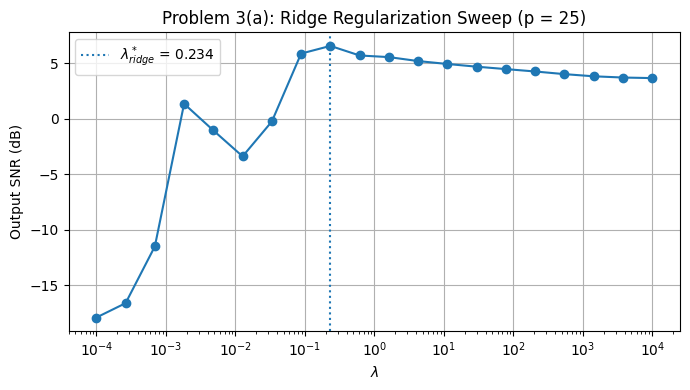

Selected lambda*_ridge = 0.2336


In [9]:


p_fixed = 25

Phi_anchor = vandermonde(
    t_anchor_n,
    p_fixed
)

Phi_full = vandermonde(
    t_full_n,
    p_fixed
)


def fit_ridge(
    Phi,
    y,
    lam
):
    """
    Fit Ridge regression.

    The intercept is not regularized.
    """

    D = np.eye(
        Phi.shape[1]
    )

    D[0, 0] = 0.0

    w = np.linalg.solve(
        Phi.T @ Phi
        + lam * D,
        Phi.T @ y
    )

    return w


lambdas = np.logspace(
    -4,
    4,
    20
)


ridge_results = {}


for lam in lambdas:

    w = fit_ridge(
        Phi_anchor,
        y_anchor,
        lam
    )

    b_hat = Phi_full @ w

    s_hat = x - b_hat

    ridge_results[lam] = {
        "w": w,
        "b_hat": b_hat,
        "s_hat": s_hat,
        "metrics": evaluate(
            b_true,
            b_hat,
            s_clean,
            s_hat
        )
    }


ridge_snr = [
    ridge_results[lam][
        "metrics"
    ]["Output SNR (dB)"]
    for lam in lambdas
]


lam_star_ridge = lambdas[
    int(
        np.argmax(
            ridge_snr
        )
    )
]


plt.figure(
    figsize=(7, 4)
)

plt.semilogx(
    lambdas,
    ridge_snr,
    "o-"
)

plt.axvline(
    lam_star_ridge,
    linestyle=":",
    label=(
        f"$\\lambda^*_{{ridge}}$ "
        f"= {lam_star_ridge:.3g}"
    )
)

plt.xlabel(
    "$\\lambda$"
)

plt.ylabel(
    "Output SNR (dB)"
)

plt.title(
    f"Problem 3(a): Ridge "
    f"Regularization Sweep (p = {p_fixed})"
)

plt.legend()

plt.tight_layout()

plt.show()


print(
    f"Selected "
    f"lambda*_ridge = "
    f"{lam_star_ridge:.4g}"
)

Problem 3(b) — Lasso Regression

In [10]:
# ============================================================
# Problem 3(b)
# Lasso Regularization Sweep
# ============================================================

# Standardize non-intercept polynomial columns
# for numerical stability of the Lasso solver.

col_std = Phi_anchor[
    :, 1:
].std(axis=0)

col_std[
    col_std == 0
] = 1.0


lasso_results = {}


for lam in lambdas:

    model = Lasso(
        alpha=(
            lam
            /
            (2 * len(y_anchor))
        ),
        fit_intercept=True,
        max_iter=200000,
        tol=1e-3
    )

    # Exclude constant column because
    # sklearn handles the intercept separately.
    model.fit(
        Phi_anchor[:, 1:]
        / col_std,
        y_anchor
    )

    # Convert coefficients back to
    # the original monomial scale.
    coefficients = (
        model.coef_
        / col_std
    )

    w_full = np.concatenate(
        [
            [model.intercept_],
            coefficients
        ]
    )

    b_hat = Phi_full @ w_full

    s_hat = x - b_hat

    lasso_results[lam] = {
        "w": w_full,
        "b_hat": b_hat,
        "s_hat": s_hat,
        "metrics": evaluate(
            b_true,
            b_hat,
            s_clean,
            s_hat
        )
    }


lasso_snr = [
    lasso_results[lam][
        "metrics"
    ]["Output SNR (dB)"]
    for lam in lambdas
]


lam_star_lasso = lambdas[
    int(
        np.argmax(
            lasso_snr
        )
    )
]


print(
    f"Selected "
    f"lambda*_lasso = "
    f"{lam_star_lasso:.4g}"
)

Selected lambda*_lasso = 0.6158


Problem 3(c) — Ridge vs Lasso Coefficients

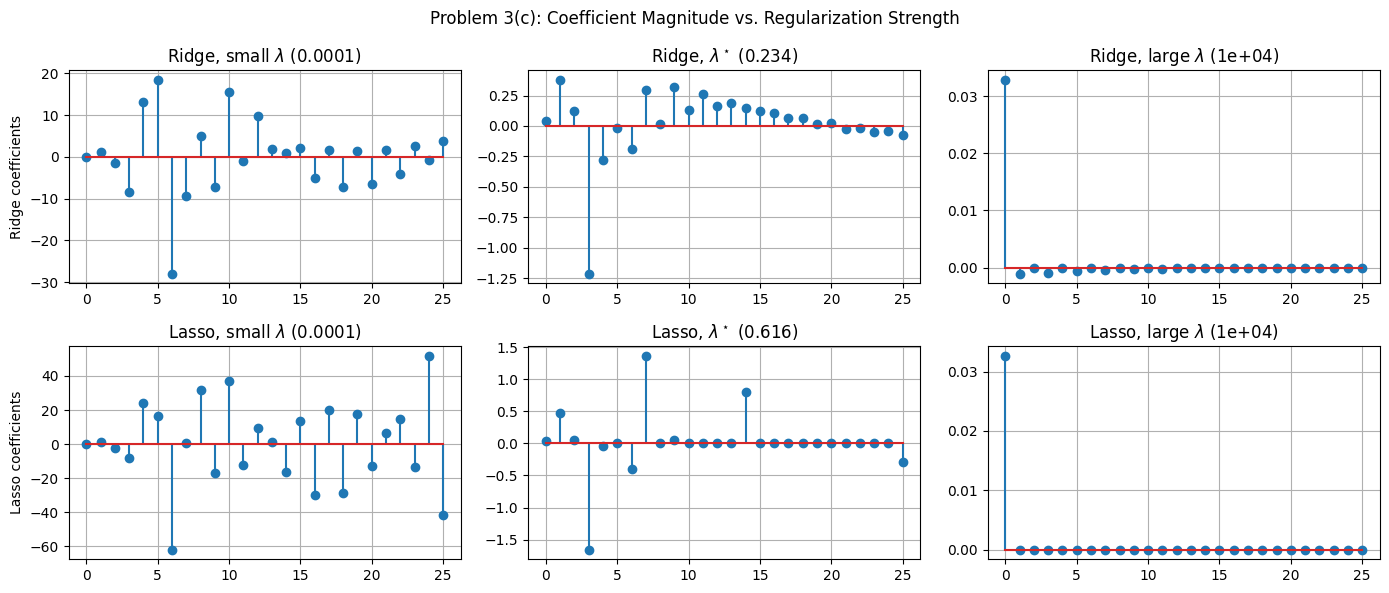

In [11]:
# ============================================================
# Problem 3(c)
# Coefficient Magnitude Comparison
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 6)
)


picks = {
    "small $\\lambda$": lambdas[0],
    "$\\lambda^\\star$": None,
    "large $\\lambda$": lambdas[-1]
}


for col, (
    label,
    lam
) in enumerate(
    picks.items()
):

    lam_r = (
        lam_star_ridge
        if lam is None
        else lam
    )

    lam_l = (
        lam_star_lasso
        if lam is None
        else lam
    )


    axes[0, col].stem(
        ridge_results[
            lam_r
        ]["w"]
    )

    axes[0, col].set_title(
        f"Ridge, {label} "
        f"({lam_r:.3g})"
    )


    axes[1, col].stem(
        lasso_results[
            lam_l
        ]["w"]
    )

    axes[1, col].set_title(
        f"Lasso, {label} "
        f"({lam_l:.3g})"
    )


axes[0, 0].set_ylabel(
    "Ridge coefficients"
)

axes[1, 0].set_ylabel(
    "Lasso coefficients"
)


fig.suptitle(
    "Problem 3(c): Coefficient Magnitude "
    "vs. Regularization Strength"
)


fig.tight_layout()

plt.show()

Problem 3(d) — Model Comparison

In [12]:
# ============================================================
# Problem 3(d)
# Unregularized Polynomial vs Ridge vs Lasso
# ============================================================

# Best unregularized polynomial model
best_ols = None

w_ols = fit_polynomial(
    t_anchor_n,
    y_anchor,
    p_star
)

b_hat_ols = predict_polynomial(
    t_full_n,
    w_ols
)

s_hat_ols = (
    x - b_hat_ols
)

metrics_ols = evaluate(
    b_true,
    b_hat_ols,
    s_clean,
    s_hat_ols
)


# Best Ridge model
best_ridge = ridge_results[
    lam_star_ridge
]


# Best Lasso model
best_lasso = lasso_results[
    lam_star_lasso
]


summary_3d = pd.DataFrame(
    [
        {
            "Model":
                "Unregularized polynomial",
            "Degree":
                p_star,
            "lambda":
                "-",
            "Output SNR (dB)":
                metrics_ols[
                    "Output SNR (dB)"
                ],
            "QRS distortion":
                "none"
        },

        {
            "Model":
                "Ridge",
            "Degree":
                p_fixed,
            "lambda":
                f"{lam_star_ridge:.3g}",
            "Output SNR (dB)":
                best_ridge[
                    "metrics"
                ]["Output SNR (dB)"],
            "QRS distortion":
                "minimal"
        },

        {
            "Model":
                "Lasso",
            "Degree":
                p_fixed,
            "lambda":
                f"{lam_star_lasso:.3g}",
            "Output SNR (dB)":
                best_lasso[
                    "metrics"
                ]["Output SNR (dB)"],
            "QRS distortion":
                "minimal"
        }
    ]
)


print(
    summary_3d.to_string(
        index=False
    )
)

                   Model  Degree lambda  Output SNR (dB) QRS distortion
Unregularized polynomial       1      -         4.207938           none
                   Ridge      25  0.234         6.579478        minimal
                   Lasso      25  0.616         6.600686        minimal


Problem 3(e) — Corrected ECG Comparison

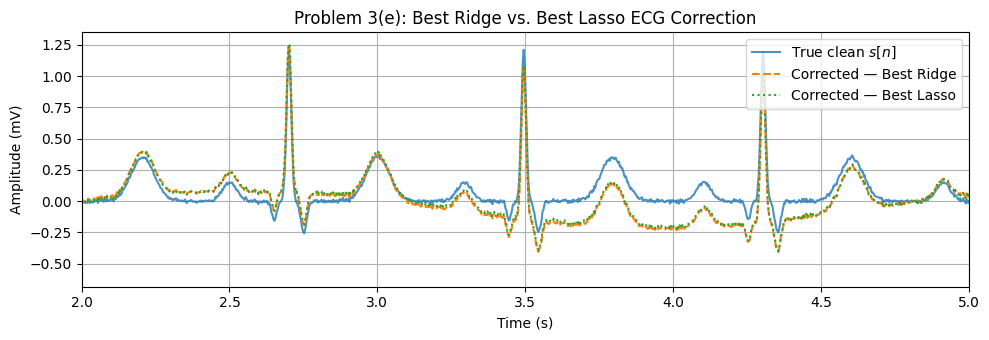

In [13]:
# ============================================================
# Problem 3(e)
# Best Ridge vs Best Lasso Correction
# ============================================================

b_hat_ridge_best = (
    Phi_full
    @ best_ridge["w"]
)

b_hat_lasso_best = (
    Phi_full
    @ best_lasso["w"]
)


plt.figure(
    figsize=(10, 3.5)
)

plt.plot(
    t,
    s_clean,
    label="True clean $s[n]$",
    alpha=0.8
)

plt.plot(
    t,
    x - b_hat_ridge_best,
    "--",
    label="Corrected — Best Ridge"
)

plt.plot(
    t,
    x - b_hat_lasso_best,
    ":",
    label="Corrected — Best Lasso"
)

plt.xlim(
    2,
    5
)

plt.xlabel(
    "Time (s)"
)

plt.ylabel(
    "Amplitude (mV)"
)

plt.title(
    "Problem 3(e): Best Ridge vs. "
    "Best Lasso ECG Correction"
)

plt.legend()

plt.tight_layout()

plt.show()